# Caso de negociio clasificación de clientes
## Modelo de RFM - Modelo K- Means

In [ ]:
# Fase importación Datos



In [17]:
## Importar Librerias
! pip install seaborn
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')




[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
# Configuración de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [42]:
# Cargar datos
# Nota: Ajusta la ruta si el archivo está en otra ubicación
df = pd.read_csv('usos_parques_2024_2025.csv', encoding='utf-8')

print("✅ Datos cargados correctamente")
print(f"Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")
print("\nPrimeras 5 filas:")
df.head()

✅ Datos cargados correctamente
Dimensiones: 79117 filas, 12 columnas

Primeras 5 filas:


,code_anon,genero,fechanacimiento,fecha,hora,codsede,codproducto,valor_neto,valor_descuento,tarifa,grupo,tipo_venta
0,ID_d91be8edb096,Femenino,1977-01-09,2025-05-25,11.0,721.0,24.0,0.0,4700,TA,Cortesias web 2-Apl,Individual
1,ID_6d1b7b46e8f8,Masculino,1971-12-20,2025-05-25,11.0,722.0,24.0,4800.0,0,TB,NaN,Individual
2,ID_565bd74de162,Masculino,1963-10-28,2025-05-25,8.0,721.0,24.0,21400.0,0,TC,Adulto mayor no afi. parques,Individual
3,ID_ca7d0706f01b,Femenino,2006-03-16,2025-05-25,10.0,723.0,504.0,3100.0,0,TB,NaN,Individual
4,ID_b7edbab69874,Femenino,1988-02-07,2025-05-25,16.0,723.0,504.0,4300.0,0,TC,NaN,Individual


In [43]:
df_parques = pd.read_csv('usos_parques_2024_2025.csv')

In [44]:
#  Exploración inicial y tipos de datos
# ============================
print("\n=== Información del Dataset ===")
df.info()

print("\n=== Estadísticas descriptivas (numéricas) ===")
display(df.describe())

print("\n=== Valores nulos por columna ===")
print(df.isnull().sum())

print("\n=== Revisión de valores únicos en columnas categóricas clave ===")
categorical_cols = ['genero', 'codsede', 'tarifa', 'grupo', 'tipo_venta']
for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col}: {df[col].nunique()} valores únicos")
        print(df[col].value_counts().head(10))


=== Información del Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 79117 entries, 0 to 79116
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   code_anon        79117 non-null  str    
 1   genero           79117 non-null  str    
 2   fechanacimiento  79117 non-null  str    
 3   fecha            79117 non-null  str    
 4   hora             79117 non-null  float64
 5   codsede          79117 non-null  float64
 6   codproducto      79117 non-null  float64
 7   valor_neto       79117 non-null  float64
 8   valor_descuento  79117 non-null  int64  
 9   tarifa           79117 non-null  str    
 10  grupo            36865 non-null  str    
 11  tipo_venta       79117 non-null  str    
dtypes: float64(4), int64(1), str(7)
memory usage: 7.2 MB

=== Estadísticas descriptivas (numéricas) ===


,hora,codsede,codproducto,valor_neto,valor_descuento
count,79117.000000,79117.000000,79117.000000,79117.000000,79117.000000
mean,11.707016,745.120328,61.569701,5131.543158,1961.685858
std,2.764458,106.959486,138.409358,7598.035176,5532.227520
min,6.000000,721.000000,24.000000,0.000000,0.000000
25%,10.000000,721.000000,24.000000,0.000000,0.000000
50%,11.000000,723.000000,24.000000,4200.000000,0.000000
75%,13.000000,723.000000,24.000000,4700.000000,0.000000
max,22.000000,1518.000000,1182.000000,36400.000000,36400.000000



=== Valores nulos por columna ===
code_anon              0
genero                 0
fechanacimiento        0
fecha                  0
hora                   0
codsede                0
codproducto            0
valor_neto             0
valor_descuento        0
tarifa                 0
grupo              42252
tipo_venta             0
dtype: int64

=== Revisión de valores únicos en columnas categóricas clave ===

genero: 2 valores únicos
genero
Femenino     41962
Masculino    37155
Name: count, dtype: int64

codsede: 16 valores únicos
codsede
723.0     27184
721.0     23608
722.0     14359
779.0      7589
724.0      4062
1518.0      943
1116.0      482
1099.0      292
1096.0      219
1504.0      155
Name: count, dtype: int64

tarifa: 260 valores únicos
tarifa
TA                    50399
TD                     9018
Abierto al Público     7299
TB                     4681
TC                     2538
ta                      650
TA                      384
TA                      349
  TA    

In [22]:
# Limpieza y estandarización de datos
# ============================

# Estandarizar formato de fechas (columna 'fecha')
# Hay formatos como '2025-05-25', '20250525', '25/05/2025', '05/25/2025', '2025/05/25', etc.
def parse_fecha(date_str):
    if pd.isna(date_str):
        return np.nan
    date_str = str(date_str).strip()
    # Reemplazar separadores comunes
    for sep in ['/', '-']:
        if sep in date_str:
            parts = date_str.split(sep)
            if len(parts) == 3:
                # Si el año tiene 2 dígitos? No, todos son 4, pero por si acaso
                if len(parts[0]) == 4:  # formato YYYY/MM/DD
                    return pd.to_datetime(f"{parts[0]}-{parts[1]}-{parts[2]}")
                elif len(parts[2]) == 4:  # formato DD/MM/YYYY o MM/DD/YYYY
                    # Intentar primero asumir DD/MM/YYYY, si falla será MM/DD/YYYY
                    try:
                        return pd.to_datetime(f"{parts[2]}-{parts[1]}-{parts[0]}")
                    except:
                        return pd.to_datetime(f"{parts[2]}-{parts[0]}-{parts[1]}")
    # Si es solo números tipo '20250525'
    if date_str.isdigit() and len(date_str) == 8:
        return pd.to_datetime(date_str, format='%Y%m%d')
    # Intentar con pandas flexible
    try:
        return pd.to_datetime(date_str)
    except:
        return np.nan

df['fecha_parse'] = df['fecha'].apply(parse_fecha)
# Verificar parseo exitoso
print(f"\nFechas parseadas correctamente: {df['fecha_parse'].notna().sum()} de {len(df)}")
# Mostrar algunos problemas si existen
if df['fecha_parse'].isna().sum() > 0:
    print("Ejemplos de fechas no parseadas:")
    print(df[df['fecha_parse'].isna()]['fecha'].unique()[:5])



Fechas parseadas correctamente: 79117 de 79117


In [23]:
# Estandarizar 'hora' (parece estar como float, pero representa hora)
df['hora'] = df['hora'].astype(float)  # asegurar numérico
# Crear categoría horaria (mañana, tarde, noche)
def periodo_hora(h):
    if pd.isna(h):
        return 'Desconocido'
    if h < 12:
        return 'Mañana (6-11h)'
    elif h < 18:
        return 'Tarde (12-17h)'
    else:
        return 'Noche (18-23h)'
df['periodo'] = df['hora'].apply(periodo_hora)

In [ ]:
# Limpiar columnas categóricas (quitar espacios, estandarizar mayúsculas)
categoricas = ['genero', 'codsede', 'tarifa', 'grupo', 'tipo_venta']
for col in categoricas:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.upper()
        # Reemplazar valores nulos o 'NAN' por 'DESCONOCIDO'
        df[col] = df[col].replace(['NAN', 'NONE', ''], 'DESCONOCIDO')

#  Estandarizar 'tarifa' (TA, TB, TC, TD, etc.) y 'grupo' (descripción)
# Ya está, pero limpiar espacios extra.

#  Columnas numéricas: valor_neto, valor_descuento (parecen correctas)
# Convertir a numérico forzando errores a NaN
for col in ['valor_neto', 'valor_descuento']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
#  Crear columna de edad a partir de 'fechanacimiento'
def parse_fecha_nac(fecha_str):
    if pd.isna(fecha_str):
        return np.nan
    fecha_str = str(fecha_str).strip()
    # Reutilizar la función parse_fecha pero solo para fechas de nacimiento
    # Como puede haber años 1895 (error), lo manejamos
    try:
        fecha = parse_fecha(fecha_str)
        if pd.notna(fecha) and fecha.year > 1900 and fecha.year <= datetime.now().year:
            return fecha
        else:
            return np.nan
    except:
        return np.nan

df['fechanacimiento_parse'] = df['fechanacimiento'].apply(parse_fecha_nac)
# Calcular edad (usando fecha_parse como referencia, si existe, sino usar 2025-06-11 como fecha de corte)
fecha_referencia = df['fecha_parse'].max() if df['fecha_parse'].notna().any() else pd.to_datetime('2025-06-11')
df['edad'] = (fecha_referencia - df['fechanacimiento_parse']).dt.days // 365
# Limitar edades razonables (0 a 120 años)
df['edad'] = df['edad'].clip(0, 120)


In [47]:
df.columns

Index(['code_anon', 'genero', 'fechanacimiento', 'fecha', 'hora', 'codsede',
       'codproducto', 'valor_neto', 'valor_descuento', 'tarifa', 'grupo',
       'tipo_venta'],
      dtype='str')

In [ ]:
# Crear columna año-mes para análisis temporal
df['año_mes'] = df['fecha_parse'].dt.to_period('M')


In [48]:
df.columns

Index(['code_anon', 'genero', 'fechanacimiento', 'fecha', 'hora', 'codsede',
       'codproducto', 'valor_neto', 'valor_descuento', 'tarifa', 'grupo',
       'tipo_venta'],
      dtype='str')

# ============================
# Análisis exploratorio y visualizaciones
# ============================

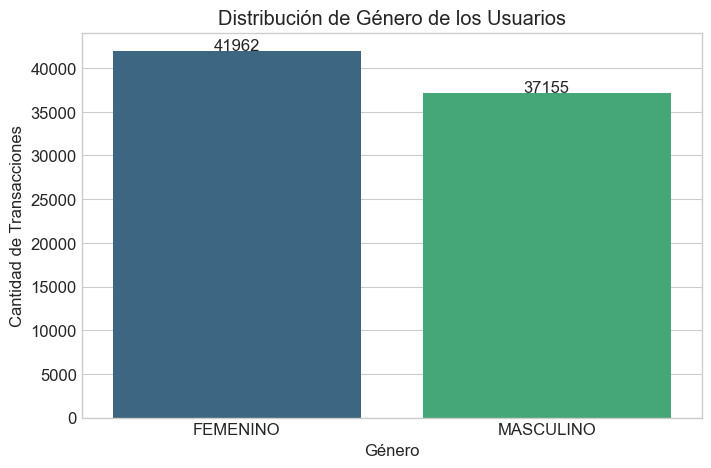

In [27]:
# Distribución de género
plt.figure(figsize=(8,5))
gender_counts = df['genero'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='viridis')
plt.title('Distribución de Género de los Usuarios')
plt.xlabel('Género')
plt.ylabel('Cantidad de Transacciones')
for i, v in enumerate(gender_counts.values):
    plt.text(i, v+50, str(v), ha='center')
plt.show()


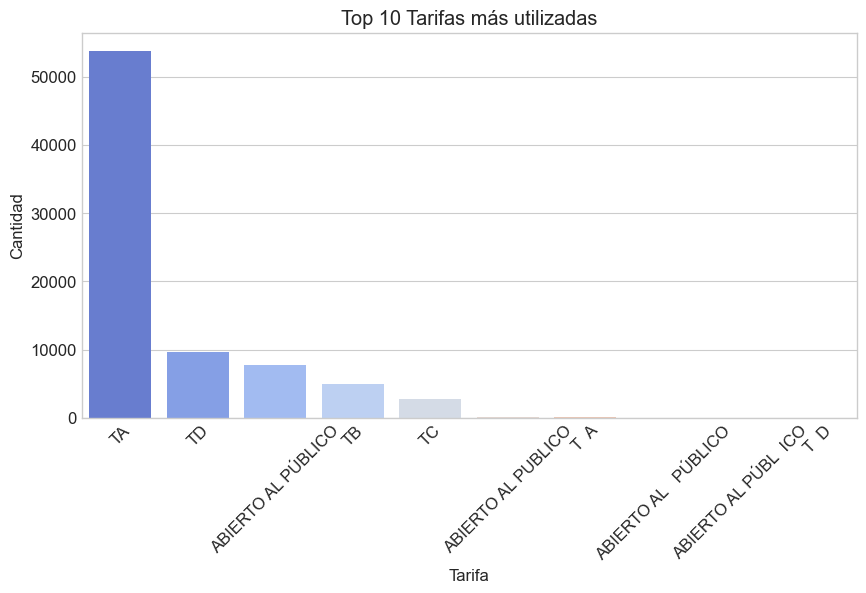

In [ ]:
# Distribución de tarifas (TA, TB, TC, TD, etc.)
plt.figure(figsize=(10,5))
tarifa_counts = df['tarifa'].value_counts().head(10)
sns.barplot(x=tarifa_counts.index, y=tarifa_counts.values, palette='coolwarm')
plt.title('Top 10 Tarifas más utilizadas')
plt.xlabel('Tarifa')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

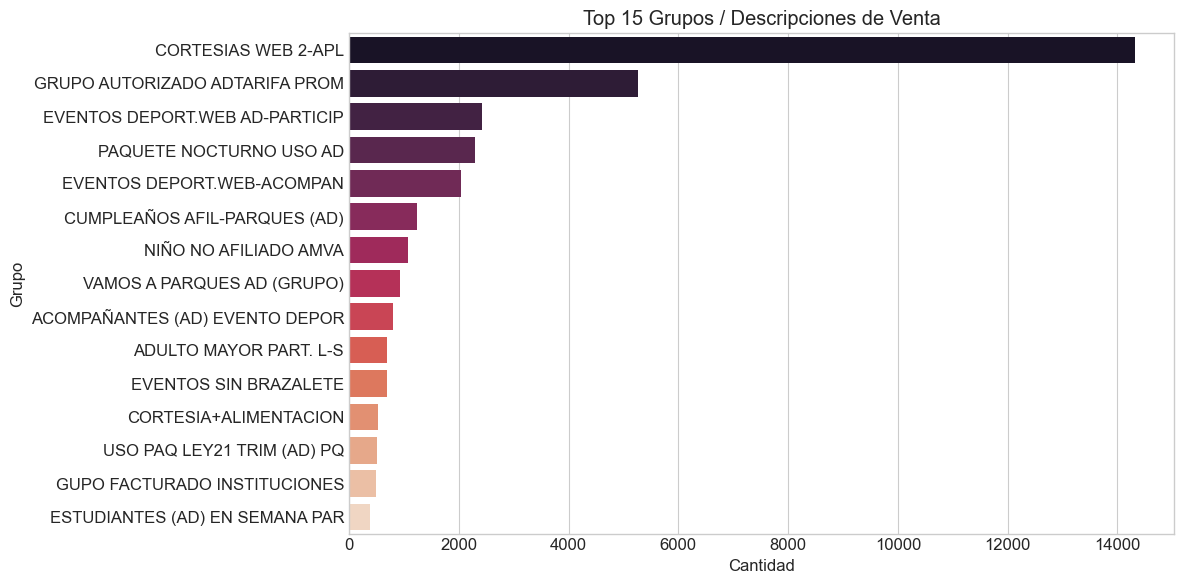

In [29]:
# Distribución de grupos (descripción)
plt.figure(figsize=(12,6))
grupo_counts = df['grupo'].value_counts().head(15)
sns.barplot(y=grupo_counts.index, x=grupo_counts.values, palette='rocket')
plt.title('Top 15 Grupos / Descripciones de Venta')
plt.xlabel('Cantidad')
plt.ylabel('Grupo')
plt.tight_layout()
plt.show()

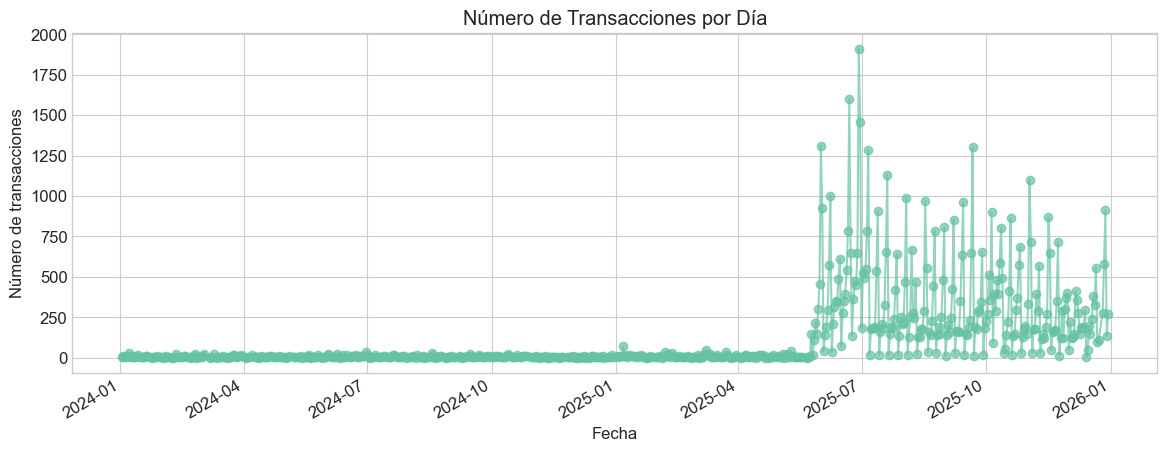

In [30]:
# Tendencia de transacciones por día (serie temporal)
plt.figure(figsize=(14,5))
daily_counts = df['fecha_parse'].value_counts().sort_index()
daily_counts.plot(kind='line', marker='o', linestyle='-', alpha=0.7)
plt.title('Número de Transacciones por Día')
plt.xlabel('Fecha')
plt.ylabel('Número de transacciones')
plt.grid(True)
plt.show()

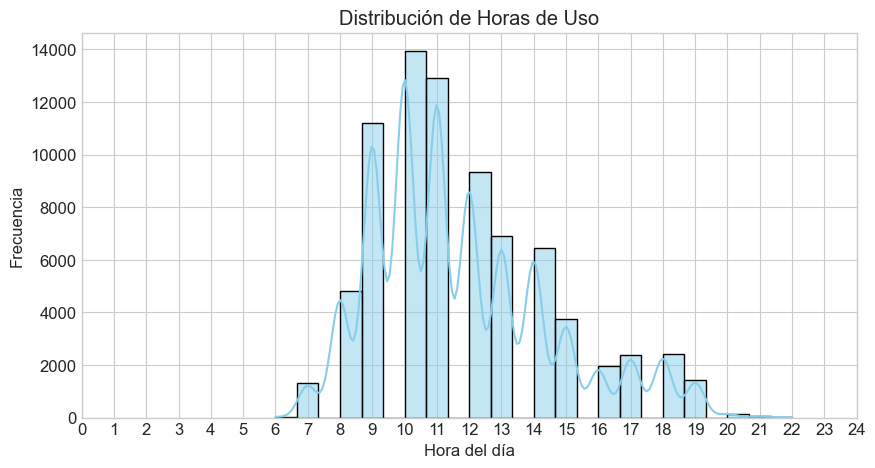

In [31]:
# Distribución de horas de uso
plt.figure(figsize=(10,5))
sns.histplot(df['hora'].dropna(), bins=24, kde=True, color='skyblue')
plt.title('Distribución de Horas de Uso')
plt.xlabel('Hora del día')
plt.ylabel('Frecuencia')
plt.xticks(range(0,25))
plt.show()

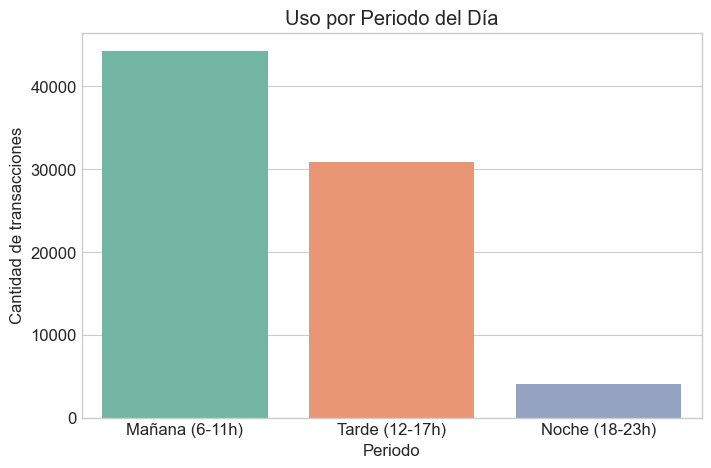

In [ ]:
# Periodo del día (mañana, tarde, noche)
plt.figure(figsize=(8,5))
periodo_counts = df['periodo'].value_counts()
sns.barplot(x=periodo_counts.index, y=periodo_counts.values, palette='Set2')
plt.title('Uso por Periodo del Día')
plt.xlabel('Periodo')
plt.ylabel('Cantidad de transacciones')
plt.show()


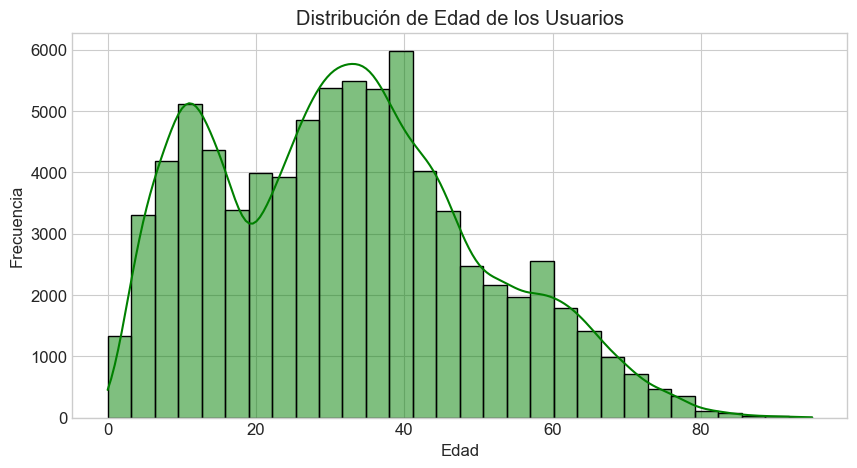

In [33]:
# Distribución de edad (histograma)
plt.figure(figsize=(10,5))
sns.histplot(df['edad'].dropna(), bins=30, kde=True, color='green')
plt.title('Distribución de Edad de los Usuarios')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

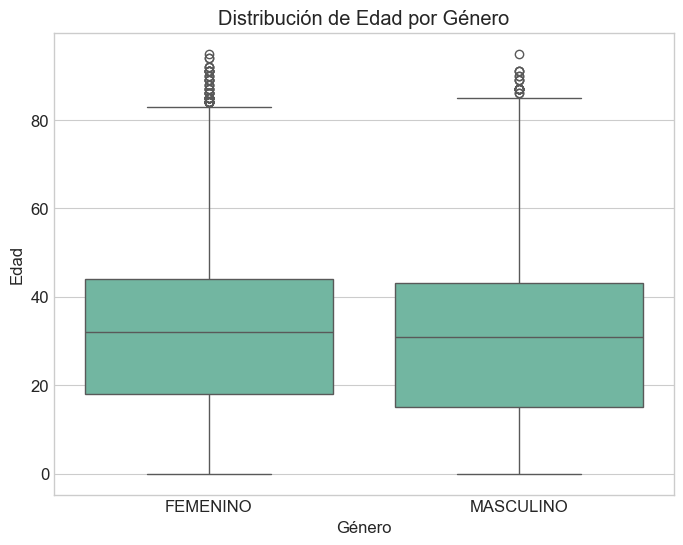

In [34]:
# Boxplot de edad por género
plt.figure(figsize=(8,6))
sns.boxplot(x='genero', y='edad', data=df[df['genero'].isin(['FEMENINO', 'MASCULINO'])])
plt.title('Distribución de Edad por Género')
plt.xlabel('Género')
plt.ylabel('Edad')
plt.show()

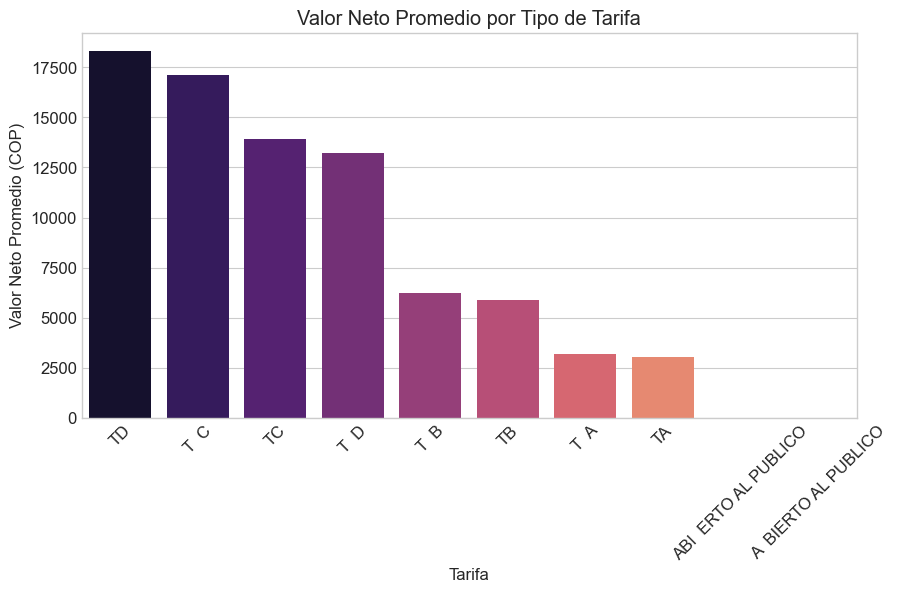

In [35]:
# Valor neto promedio por tarifa
plt.figure(figsize=(10,5))
avg_valor = df.groupby('tarifa')['valor_neto'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=avg_valor.index, y=avg_valor.values, palette='magma')
plt.title('Valor Neto Promedio por Tipo de Tarifa')
plt.xlabel('Tarifa')
plt.ylabel('Valor Neto Promedio (COP)')
plt.xticks(rotation=45)
plt.show()


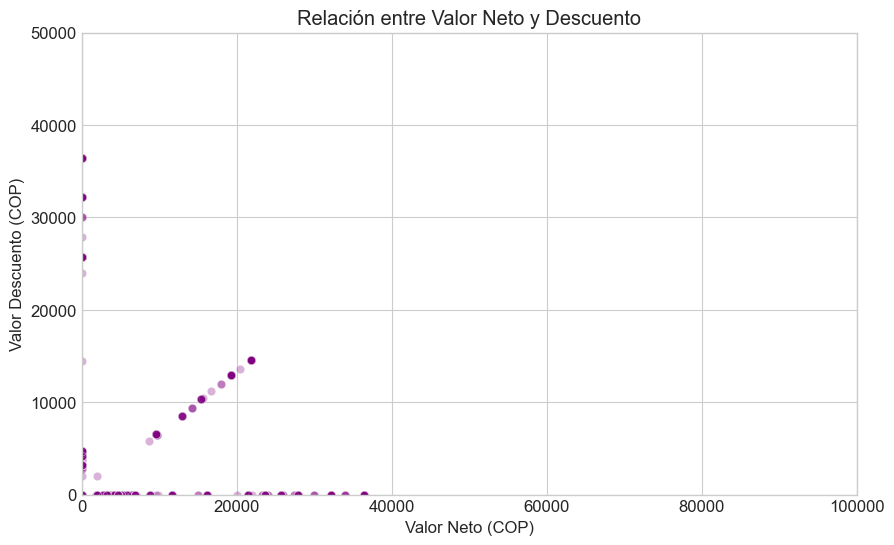

In [36]:
# Relación entre valor neto y descuento (scatter plot)
plt.figure(figsize=(10,6))
sample = df.sample(min(5000, len(df)))  # muestra para no sobrecargar
sns.scatterplot(data=sample, x='valor_neto', y='valor_descuento', alpha=0.3, color='purple')
plt.title('Relación entre Valor Neto y Descuento')
plt.xlabel('Valor Neto (COP)')
plt.ylabel('Valor Descuento (COP)')
plt.xlim(0, 100000)
plt.ylim(0, 50000)
plt.show()

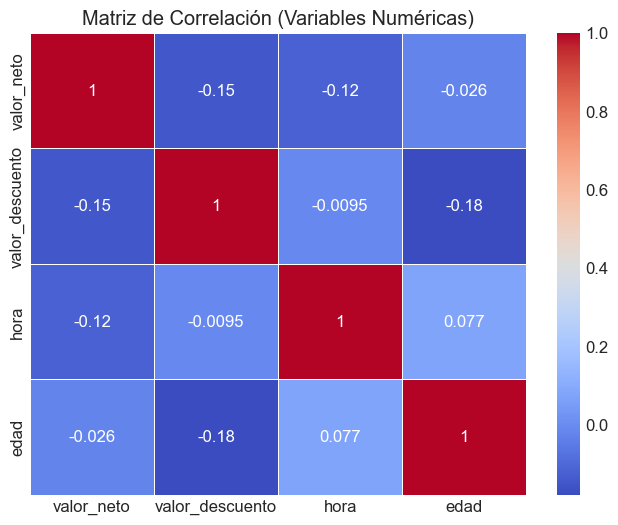

In [37]:
# Mapa de calor de correlaciones entre variables numéricas
numeric_df = df[['valor_neto', 'valor_descuento', 'hora', 'edad']].dropna()
corr = numeric_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación (Variables Numéricas)')
plt.show()


In [38]:
# ============================
# Resumen de hallazgos (output textual)
# ============================

print("\n=== RESUMEN DEL ANÁLISIS EXPLORATORIO ===")
print(f"1. Rango de fechas: desde {df['fecha_parse'].min()} hasta {df['fecha_parse'].max()}")
print(f"2. Total de transacciones únicas: {df['code_anon'].nunique()}")
print(f"3. Porcentaje de missing en fecha de nacimiento: {df['fechanacimiento_parse'].isna().mean()*100:.1f}%")
print(f"4. Tarifa más común: {df['tarifa'].mode()[0]} ({df['tarifa'].value_counts().iloc[0]} transacciones)")
print(f"5. Género predominante: {df['genero'].value_counts().index[0]} ({df['genero'].value_counts().iloc[0]} transacciones)")
print(f"6. Edad promedio: {df['edad'].mean():.1f} años (mediana: {df['edad'].median():.1f})")
print(f"7. Valor neto promedio: ${df['valor_neto'].mean():,.0f} COP")
print(f"8. Horario de mayor afluencia: {df['periodo'].mode()[0]}")

# Guardar datos limpios (opcional)
# df_clean = df.copy()
# df_clean.to_csv('datos_parques_limpios.csv', index=False)
print("\n✅ Análisis completado. Datos limpios listos para modelado.")



=== RESUMEN DEL ANÁLISIS EXPLORATORIO ===
1. Rango de fechas: desde 2024-01-02 00:00:00 hasta 2025-12-30 00:00:00
2. Total de transacciones únicas: 71814
3. Porcentaje de missing en fecha de nacimiento: 0.0%
4. Tarifa más común: TA (53740 transacciones)
5. Género predominante: FEMENINO (41962 transacciones)
6. Edad promedio: 31.9 años (mediana: 31.0)
7. Valor neto promedio: $5,132 COP
8. Horario de mayor afluencia: Mañana (6-11h)

✅ Análisis completado. Datos limpios listos para modelado.


In [10]:

# Miremos dimensiones en catidades
print("Dimensiones:", df_parques.shape)
df_parques2 = pd.read_csv('usos_parques_2024_2025.csv')

Dimensiones: (79117, 12)


In [ ]:
# Miremos el nombre de las columnas
df_parques.columns

Index(['code_anon', 'genero', 'fechanacimiento', 'fecha', 'hora', 'codsede',
       'codproducto', 'valor_neto', 'valor_descuento', 'tarifa', 'grupo',
       'tipo_venta'],
      dtype='str')

In [49]:
df_parques.head(5)


,code_anon,genero,fechanacimiento,fecha,hora,codsede,codproducto,valor_neto,valor_descuento,tarifa,grupo,tipo_venta
0,ID_d91be8edb096,Femenino,1977-01-09,2025-05-25,11.0,721.0,24.0,0.0,4700,TA,Cortesias web 2-Apl,Individual
1,ID_6d1b7b46e8f8,Masculino,1971-12-20,2025-05-25,11.0,722.0,24.0,4800.0,0,TB,NaN,Individual
2,ID_565bd74de162,Masculino,1963-10-28,2025-05-25,8.0,721.0,24.0,21400.0,0,TC,Adulto mayor no afi. parques,Individual
3,ID_ca7d0706f01b,Femenino,2006-03-16,2025-05-25,10.0,723.0,504.0,3100.0,0,TB,NaN,Individual
4,ID_b7edbab69874,Femenino,1988-02-07,2025-05-25,16.0,723.0,504.0,4300.0,0,TC,NaN,Individual


In [50]:
df_parques.tail(5)

,code_anon,genero,fechanacimiento,fecha,hora,codsede,codproducto,valor_neto,valor_descuento,tarifa,grupo,tipo_venta
79112,ID_dbaa5f243423,Masculino,2004-01-23,06/29/2025,10.0,721.0,24.0,4700.0,0,TA,NaN,Individual
79113,ID_0c06ef8d63ab,Femenino,1997-08-15,20240331,11.0,723.0,24.0,4500.0,0,TA,NaN,individual
79114,ID_14d160a8cc3f,Femenino,1989-04-29,2025-09-16,14.0,723.0,24.0,0.0,4700,TA,Cortesias web 2-Apl,Individual
79115,ID_ce4606680ab6,Masculino,1996-10-07,2024-06-23,14.0,721.0,24.0,30000.0,0,TD,NaN,Individual
79116,ID_61fe2260b2af,Masculino,1985-05-12,2025-03-08,11.0,779.0,24.0,0.0,4200,TA,Cortesias web 2-Apl,Individual


In [16]:
# Veamos algunas agrupaciones

agrupar_genero=df_parques.groupby(['genero']).count()['codproducto']
print(agrupar_genero)


genero
Femenino     41962
Masculino    37155
Name: codproducto, dtype: int64


In [65]:
agrupar_sexo=df_parques.groupby(['genero','codproducto']).count()['codsede']
print(agrupar_sexo)

genero     codproducto
Femenino   24.0           37841
           136.0           1675
           145.0              1
           504.0           2232
           1109.0           213
Masculino  24.0           32264
           136.0           2983
           145.0              2
           504.0           1521
           1109.0           384
           1182.0             1
Name: codsede, dtype: int64


In [66]:
agrupar_sexo.unstack(level=0)

genero,Femenino,Masculino
codproducto,,
24.0,37841.0,32264.0
136.0,1675.0,2983.0
145.0,1.0,2.0
504.0,2232.0,1521.0
1109.0,213.0,384.0
1182.0,NaN,1.0


In [59]:
df_parques.info()


<class 'pandas.DataFrame'>
RangeIndex: 79117 entries, 0 to 79116
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   code_anon        79117 non-null  str    
 1   genero           79117 non-null  str    
 2   fechanacimiento  79117 non-null  str    
 3   fecha            79117 non-null  str    
 4   hora             79117 non-null  float64
 5   codsede          79117 non-null  float64
 6   codproducto      79117 non-null  float64
 7   valor_neto       79117 non-null  float64
 8   valor_descuento  79117 non-null  int64  
 9   tarifa           79117 non-null  str    
 10  grupo            36865 non-null  str    
 11  tipo_venta       79117 non-null  str    
dtypes: float64(4), int64(1), str(7)
memory usage: 7.2 MB


In [62]:
# como se comportan las variables categóricas
df_parques.describe(include=['O'])

C:\Users\Usuario\AppData\Local\Temp\ipykernel_13692\2129707985.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_parques.describe(include=['O'])


,code_anon,genero,fechanacimiento,fecha,tarifa,grupo,tipo_venta
count,79117,79117,79117,79117,79117,36865,79117
unique,71814,2,23138,1698,260,83,313
top,ID_f3117384e439,Femenino,1960-01-01,2025-06-29,TA,Cortesias web 2-Apl,Individual
freq,23,41962,33,1661,50399,14314,71848


In [5]:
# Estadísticas descriptivas iniciales
df_parques.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
code_anon,79117,71814,ID_f3117384e439,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genero,79117,2,Femenino,41962,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fechanacimiento,79117,23138,1960-01-01,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha,79117,1698,2025-06-29,1661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hora,79117.0,NaN,NaN,NaN,11.707016,2.764458,6.0,10.0,11.0,13.0,22.0
codsede,79117.0,NaN,NaN,NaN,745.120328,106.959486,721.0,721.0,723.0,723.0,1518.0
codproducto,79117.0,NaN,NaN,NaN,61.569701,138.409358,24.0,24.0,24.0,24.0,1182.0
valor_neto,79117.0,NaN,NaN,NaN,5131.543158,7598.035176,0.0,0.0,4200.0,4700.0,36400.0
valor_descuento,79117.0,NaN,NaN,NaN,1961.685858,5532.22752,0.0,0.0,0.0,0.0,36400.0
tarifa,79117,260,TA,50399,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ANÁLISIS DE CALIDAD DE DATOS
# =============================================
# Valores faltantes
print("Valores nulos por columna:")
print(df_parques.isnull().sum()[df_parques.isnull().sum() > 0])
print("\nPorcentaje de nulos:")
print((df_parques.isnull().sum() / len(df_parques) * 100).round(2))

Valores nulos por columna:
grupo    42252
dtype: int64

Porcentaje de nulos:
code_anon           0.0
genero              0.0
fechanacimiento     0.0
fecha               0.0
hora                0.0
codsede             0.0
codproducto         0.0
valor_neto          0.0
valor_descuento     0.0
tarifa              0.0
grupo              53.4
tipo_venta          0.0
dtype: float64


In [32]:
# 4.2 Duplicados
duplicados = df_parques.duplicated().sum()
print(f"Filas duplicadas: {duplicados} ({duplicados/len(df_parques)*100:.2f}%)")
# Mostrar algunos duplicados
df_parques[df_parques.duplicated(keep=False)].head()
# Recomendación: eliminar duplicados
df = df_parques.drop_duplicates()
print("Duplicados eliminados. Nuevo tamaño:", df.shape)

Filas duplicadas: 1478 (1.87%)
Duplicados eliminados. Nuevo tamaño: (77639, 12)


In [34]:
#  Outliers univariados (método IQR) en variables numéricas clave
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] < lower) | (data[column] > upper)]

num_cols = ['valor_neto', 'valor_descuento']
for col in num_cols:
    outliers = detect_outliers_iqr(df_parques, col)
    print(f"Outliers en {col}: {len(outliers)} ({len(outliers)/len(df_parques)*100:.1f}%)")

Outliers en valor_neto: 7590 (9.6%)
Outliers en valor_descuento: 18594 (23.5%)


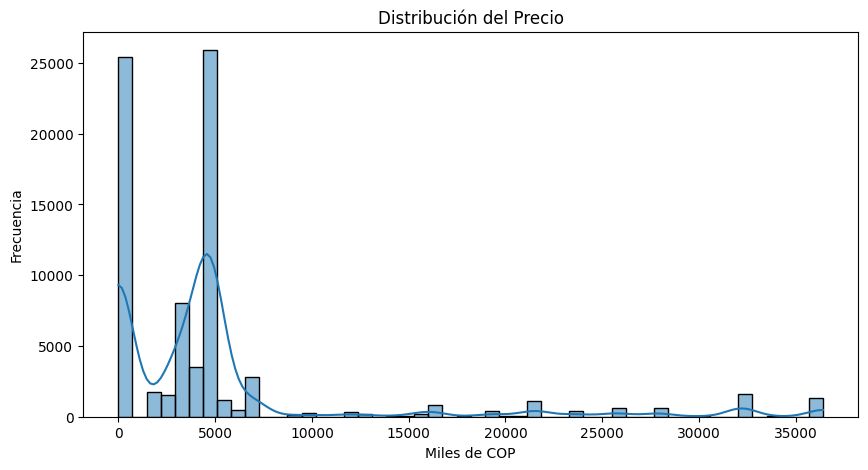

count    79117.000000
mean      5131.543158
std       7598.035176
min          0.000000
25%          0.000000
50%       4200.000000
75%       4700.000000
max      36400.000000
Name: valor_neto, dtype: float64


In [7]:
#EXPLORATORIO DE DATOS (EDA)
# =============================================
#  Distribución de la variable objetivo: precio de venta
plt.figure(figsize=(10,5))
sns.histplot(df_parques['valor_neto'], bins=50, kde=True)
plt.title('Distribución del Precio')
plt.xlabel('Miles de COP')
plt.ylabel('Frecuencia')
plt.show()

# Estadísticas de tarifa
print(df_parques['valor_neto'].describe())
# Asimetría positiva, como se espera en precios inmobiliarios
#print("Asimetría (skewness):", df_parques['frecuencia'].skew())
#print("Curtosis:", df_parques['tarifa'].kurtosis())

In [ ]:
# Mapa de calor de correlaciones numéricas
num_features = ['area_construida_m2', 'area_terreno_m2', 'estrato', 'dormitorios', 'banos',
                'edad_anios', 'parqueaderos', 'distancia_metro_m', 'precio_venta_cop']
corr = df[num_features].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()